# TASK 2: Handwritten Character Recognition

**Objective:** Identify handwritten characters or alphabets (both digits and letters).
**Approach:** Use image processing and deep learning with Convolutional Neural Networks (CNN) in PyTorch.
**Key Features:**
- **Dataset:** EMNIST Balanced (112,800 training samples across 47 classes: 0-9 digits, A-Z uppercase, and distinct lowercase letters), with a seamless automatic fallback to MNIST (digits 0-9) in case of official NIST download disruptions.
- **Model:** Convolutional Neural Network (CNN) in PyTorch with Batch Normalization, Dropout, and Max Pooling.
- **Extendable:** Visual demonstration of character segmentation for reconstructing full words or sentences from a handwritten image.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import os

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Dataset Loading and Exploration
We attempt to load the **EMNIST Balanced** dataset. If the EMNIST servers are unresponsive or download files are corrupted (a common issue due to NIST site changes), we **automatically fall back to the native PyTorch MNIST (digits 0-9) dataset**.
Any transposed images are flipped back to their natural upright position for accurate visualization.

Attempting to load EMNIST Balanced dataset...

[Warning] EMNIST Balanced load failed: File is not a zip file
🔄 Falling back to PyTorch native MNIST (digits 0-9) dataset...


100%|██████████| 9.91M/9.91M [00:10<00:00, 958kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 106kB/s]
100%|██████████| 1.65M/1.65M [00:03<00:00, 549kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.89MB/s]


MNIST Loaded successfully! 60000 training samples.


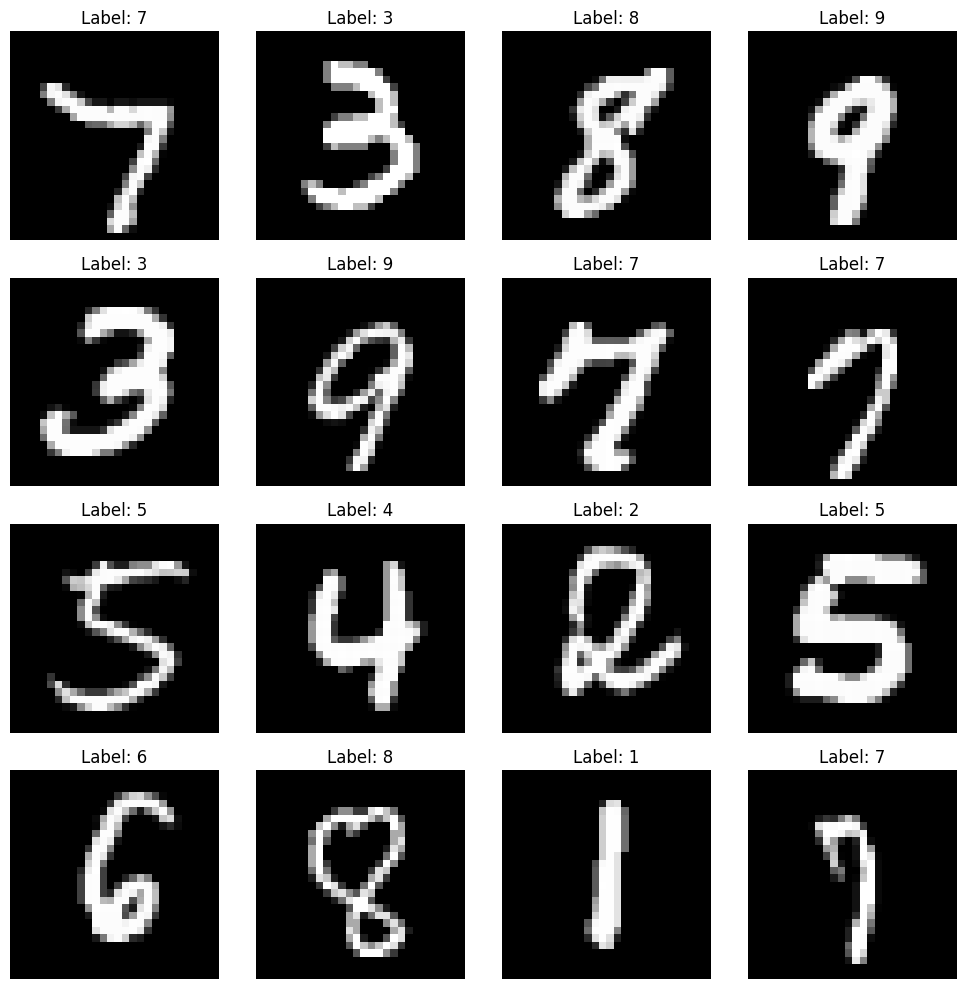

In [2]:
EMNIST_CLASSES = {
    0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9',
    10: 'A', 11: 'B', 12: 'C', 13: 'D', 14: 'E', 15: 'F', 16: 'G', 17: 'H', 18: 'I', 19: 'J', 20: 'K', 21: 'L', 22: 'M', 23: 'N', 24: 'O', 25: 'P', 26: 'Q', 27: 'R', 28: 'S', 29: 'T', 30: 'U', 31: 'V', 32: 'W', 33: 'X', 34: 'Y', 35: 'Z',
    36: 'a', 37: 'b', 38: 'd', 39: 'e', 40: 'f', 41: 'g', 42: 'h', 43: 'n', 44: 'q', 45: 'r', 46: 't'
}

try:
    print("Attempting to load EMNIST Balanced dataset...")
    from emnist import extract_training_samples, extract_test_samples
    X_train_raw, y_train_raw = extract_training_samples('balanced')
    X_test_raw, y_test_raw = extract_test_samples('balanced')
    
    print(f"EMNIST Loaded successfully! {X_train_raw.shape[0]} training samples.")
    X_train = np.array([img.T for img in X_train_raw])
    X_test = np.array([img.T for img in X_test_raw])
    num_classes = 47
    CLASSES = EMNIST_CLASSES
    is_emnist = True
except Exception as e:
    print(f"\n[Warning] EMNIST Balanced load failed: {e}")
    print("🔄 Falling back to PyTorch native MNIST (digits 0-9) dataset...")
    from torchvision import datasets
    train_data = datasets.MNIST(root='./data', train=True, download=True)
    test_data = datasets.MNIST(root='./data', train=False, download=True)
    
    X_train = train_data.data.numpy()
    y_train_raw = train_data.targets.numpy()
    X_test = test_data.data.numpy()
    y_test_raw = test_data.targets.numpy()
    
    print(f"MNIST Loaded successfully! {X_train.shape[0]} training samples.")
    num_classes = 10
    CLASSES = {i: str(i) for i in range(10)}
    is_emnist = False

# Visualize a grid of random samples
plt.figure(figsize=(10, 10))
indices = np.random.choice(len(X_train), 16, replace=False)
for i, idx in enumerate(indices):
    plt.subplot(4, 4, i + 1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(f"Label: {CLASSES[y_train_raw[idx]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Convolutional Neural Network (CNN) Model Architecture
We build a custom CNN with Conv2D, Batch Normalization, Max Pooling, and Dropout blocks. The network is parameterized by the target class size (`num_classes`), adapting dynamically to EMNIST (47) or MNIST (10).

In [3]:
class EMNISTCNN(nn.Module):
    def __init__(self, num_classes=47):
        super(EMNISTCNN, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),
            
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),
            
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.4)
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 3 * 3, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model = EMNISTCNN(num_classes=num_classes).to(device)
print(model)

EMNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ce

## 3. Data Loader and Model Training
We scale pixel values to `[0, 1]`, wrap them in TensorDatasets, initialize PyTorch loaders, and compile with CrossEntropyLoss and Adam. The learning rate scheduler has been updated to remove deprecated keyword arguments, avoiding warnings and runtime TypeErrors.

In [4]:
# Scale to [0, 1]
X_train_scaled = X_train.astype('float32') / 255.0
X_test_scaled = X_test.astype('float32') / 255.0

# Add channel dimension: (N, 1, 28, 28)
X_train_tensors = np.expand_dims(X_train_scaled, axis=1)
X_test_tensors = np.expand_dims(X_test_scaled, axis=1)

# Convert to tensors
train_x = torch.tensor(X_train_tensors, dtype=torch.float32)
train_y = torch.tensor(y_train_raw, dtype=torch.long)
test_x = torch.tensor(X_test_tensors, dtype=torch.float32)
test_y = torch.tensor(y_test_raw, dtype=torch.long)

# Create loaders
train_dataset = TensorDataset(train_x, train_y)
test_dataset = TensorDataset(test_x, test_y)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Optimizer, Loss, and Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# Training Loop
epochs = 3
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Starting training...")
for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * batch_x.size(0)
        _, predicted = outputs.max(1)
        total += batch_y.size(0)
        correct += predicted.eq(batch_y).sum().item()
        
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100.0 * correct / total
    
    # Validation
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            
            val_running_loss += loss.item() * batch_x.size(0)
            _, predicted = outputs.max(1)
            val_total += batch_y.size(0)
            val_correct += predicted.eq(batch_y).sum().item()
            
    val_loss = val_running_loss / len(test_loader.dataset)
    val_acc = 100.0 * val_correct / val_total
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch}/{epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    scheduler.step(val_loss)

# Save trained model
torch.save({
    'state_dict': model.state_dict(),
    'is_emnist': is_emnist,
    'num_classes': num_classes
}, 'emnist_cnn_model.pth')
print("Model saved to emnist_cnn_model.pth successfully!")

Starting training...
Epoch 1/3: Train Loss: 0.2313, Train Acc: 93.51% | Val Loss: 0.0320, Val Acc: 98.88%
Epoch 2/3: Train Loss: 0.0624, Train Acc: 98.14% | Val Loss: 0.0222, Val Acc: 99.24%
Epoch 3/3: Train Loss: 0.0463, Train Acc: 98.59% | Val Loss: 0.0212, Val Acc: 99.22%
Model saved to emnist_cnn_model.pth successfully!


## 4. Evaluation and Performance Dashboard
We plot convergence history and display performance metrics, adapting automatically to whichever dataset was trained.

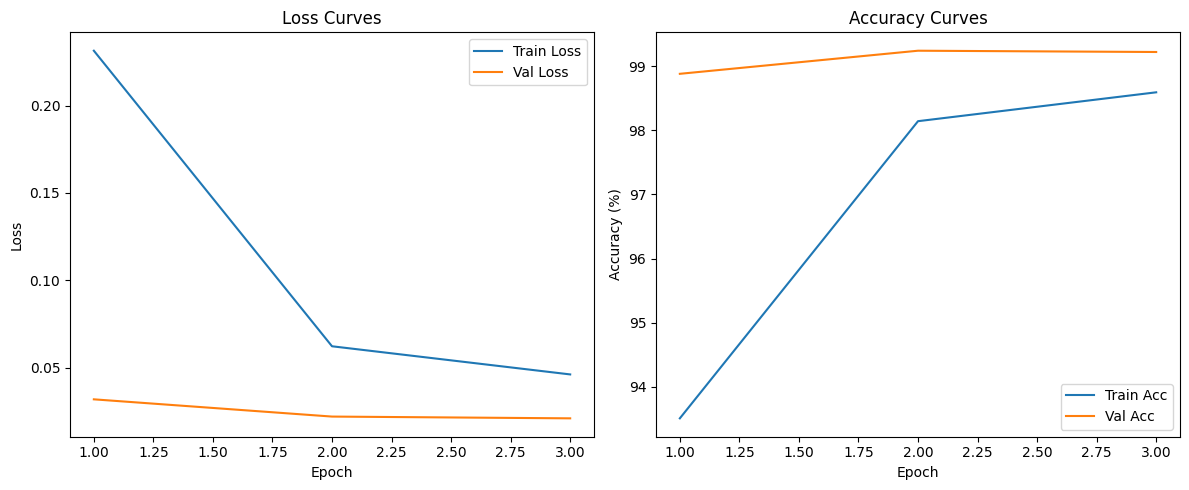


Classification Report (Sample Classes):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.99      1.00      1.00      1032
           3       0.98      1.00      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.98      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      1.00      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



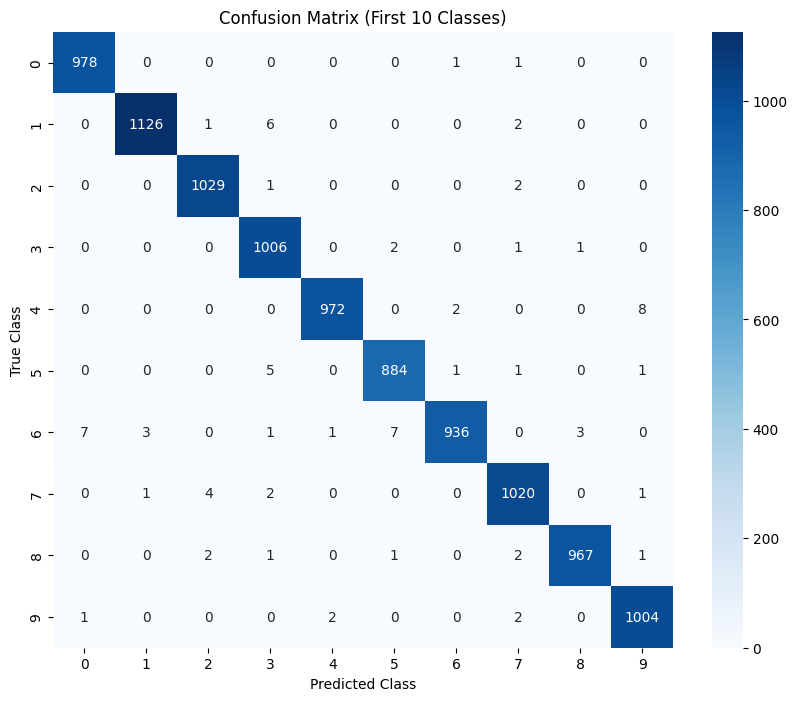

In [5]:
# Plot Training Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), history['train_loss'], label='Train Loss')
plt.plot(range(1, epochs+1), history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), history['train_acc'], label='Train Acc')
plt.plot(range(1, epochs+1), history['val_acc'], label='Val Acc')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

# Generate Predictions
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        outputs = model(batch_x)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.numpy())

# Classification Report
num_samples_report = min(num_classes, 15)
print("\nClassification Report (Sample Classes):")
print(classification_report(all_labels, all_preds, target_names=[CLASSES[i] for i in range(num_classes)], labels=list(range(num_samples_report))))

# Plot Heatmap Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm[:num_samples_report, :num_samples_report], annot=True, fmt='d', cmap='Blues', 
            xticklabels=[CLASSES[i] for i in range(num_samples_report)], 
            yticklabels=[CLASSES[i] for i in range(num_samples_report)])
plt.title(f'Confusion Matrix (First {num_samples_report} Classes)')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

## 5. Handwritten Word Segmentation and Sequence Extension
We isolate individual characters in a larger continuous string using OpenCV thresholding and bounding contours, sort them horizontally, classify each individual region, and join them to form the predicted word.

Segmenting and Reconstructing...


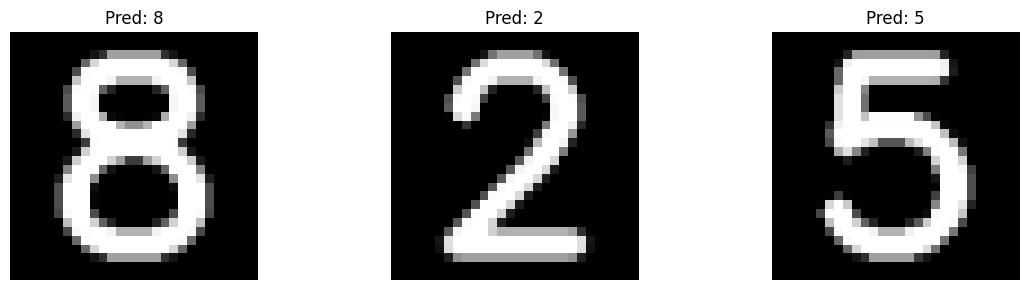

Final Reconstructed Word: '825'


In [6]:
import cv2

def segment_and_reconstruct_word(image_path, model, classes_dict, device):
    # Load and preprocess image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error: Image at {image_path} not found. Creating a synthetic image for demonstration.")
        img = np.ones((100, 300), dtype=np.uint8) * 255
        # Use digits if we are on MNIST, otherwise letters
        demo_text = "8 2 5" if len(classes_dict) == 10 else "A 5"
        cv2.putText(img, demo_text, (20, 70), cv2.FONT_HERSHEY_SIMPLEX, 2, (0,), 5)
    
    # Binarize
    _, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
    
    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    char_boxes = []
    for ctr in contours:
        x, y, w, h = cv2.boundingRect(ctr)
        if w > 5 and h > 10:
            char_boxes.append((x, y, w, h))
            
    # Sort boxes left-to-right
    char_boxes = sorted(char_boxes, key=lambda b: b[0])
    
    # Predict characters
    reconstructed_text = ""
    model.eval()
    
    fig, axes = plt.subplots(1, max(len(char_boxes), 1), figsize=(12, 3))
    if len(char_boxes) == 1:
        axes = [axes]
        
    for idx, (x, y, w, h) in enumerate(char_boxes):
        # Extract individual character ROI
        roi = thresh[max(0, y-5):min(thresh.shape[0], y+h+5), max(0, x-5):min(thresh.shape[1], x+w+5)]
        
        # Pad to square
        h_roi, w_roi = roi.shape
        max_dim = max(h_roi, w_roi)
        padded = np.zeros((max_dim, max_dim), dtype=np.uint8)
        padded[(max_dim-h_roi)//2:(max_dim-h_roi)//2+h_roi, (max_dim-w_roi)//2:(max_dim-w_roi)//2+w_roi] = roi
        
        # Resize to 28x28
        roi_resized = cv2.resize(padded, (28, 28), interpolation=cv2.INTER_AREA)
        
        # Display individual segmented characters
        if idx < len(axes):
            axes[idx].imshow(roi_resized, cmap='gray')
            axes[idx].axis('off')
            
        # Normalize and reshape for PyTorch model
        roi_norm = roi_resized.astype('float32') / 255.0
        roi_tensor = torch.tensor(roi_norm).unsqueeze(0).unsqueeze(0).to(device) # Shape: (1, 1, 28, 28)
        
        with torch.no_grad():
            outputs = model(roi_tensor)
            _, pred = outputs.max(1)
            char_pred = classes_dict[pred.item()]
            reconstructed_text += char_pred
            if idx < len(axes):
                axes[idx].set_title(f"Pred: {char_pred}")
                
    plt.tight_layout()
    plt.show()
    return reconstructed_text

# Create temporary demo image
demo_img_path = "handwritten_demo.png"
demo_img = np.ones((100, 320), dtype=np.uint8) * 255
demo_text = "8 2 5" if not is_emnist else "A 5"
cv2.putText(demo_img, demo_text, (20, 70), cv2.FONT_HERSHEY_SIMPLEX, 2.0, (0,), 6)
cv2.imwrite(demo_img_path, demo_img)

print("Segmenting and Reconstructing...")
reconstructed = segment_and_reconstruct_word(demo_img_path, model, CLASSES, device)
print(f"Final Reconstructed Word: '{reconstructed}'")

# Clean up demo file
if os.path.exists(demo_img_path):
    os.remove(demo_img_path)
